In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 220)

from dfir_copilot.engine.query_engine import QueryEngine
from dfir_copilot.engine.profiler import LogProfiler

engine = QueryEngine("/workspace/data/processed/three_months.parquet", timeout_s=120, max_rows=1000)
prof = LogProfiler(engine)
display(prof.overview().df())

,filas,desde,hasta,src_ip_distintos,user_id_distintos,session_id_distintos,endpoint_distintos,user_agent_distintos,host_distintos
0,4478619,2020-10-01 00:00:00+00,2020-12-31 23:59:00+00,5726,35,0,1,9,1


In [2]:
print("== Respuestas por User-Agent ==")
display(prof.status_by("user_agent").df())
print("== Respuestas por referer ==")
display(prof.status_by("referer").df())
print("== Actividad por IP (las 15 más activas) ==")
display(prof.activity("src_ip", n=15).df())

== Respuestas por User-Agent ==


,valor,peticiones,s2xx,s3xx,s4xx,s5xx,pct_error
0,Mozilla/5.0 (Windows NT 10.0) AppleWebKit/537....,883858,441474,147027,295357,0,33.4
1,Mozilla/5.0 (Windows NTÊx.y; Win64; x64; rv:10...,883455,441477,147925,294053,0,33.3
2,Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebK...,883021,441385,147516,294120,0,33.3
3,Mozilla/5.0 (Macintosh; Intel Mac OS XÊx.y; rv...,880728,439760,147305,293663,0,33.3
4,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,880522,440763,146577,293182,0,33.3
5,crawler4j,24140,17555,0,6585,0,27.3
6,Scrapy/2.3.0 (+https://scrapy.org),24053,17504,0,6549,0,27.2
7,wget,13768,13768,0,0,0,0.0
8,PostmanRuntime/7.25.0,5074,5074,0,0,0,0.0


== Respuestas por referer ==


,valor,peticiones,s2xx,s3xx,s4xx,s5xx,pct_error
0,https://mercadolibre.com/billing,4457578,2250853,736350,1470375,0,33.0
1,google.com,10634,3963,0,6671,0,62.7
2,NaN,10407,3944,0,6463,0,62.1


== Actividad por IP (las 15 más activas) ==


,entidad,peticiones,endpoints,ips,usuarios,user_agents,primera,ultima,pct_error
0,73.130.229.200,12453,1,1,4,3,2020-10-01 00:19:00+00,2020-12-31 23:47:00+00,21.5
1,216.21.168.27,12429,1,1,4,3,2020-10-01 00:00:00+00,2020-12-31 23:54:00+00,20.8
2,74.88.210.56,12426,1,1,4,3,2020-10-01 01:41:00+00,2020-12-31 23:57:00+00,21.1
3,204.210.158.207,12409,1,1,4,3,2020-10-01 06:09:00+00,2020-12-31 23:52:00+00,20.8
4,24.163.83.34,12244,1,1,4,3,2020-10-01 00:45:00+00,2020-12-31 23:54:00+00,21.8
5,181.88.192.48,3010,1,1,31,6,2020-11-01 00:00:00+00,2020-12-31 22:55:00+00,21.9
6,181.88.192.87,2961,1,1,31,6,2020-11-01 01:34:00+00,2020-12-31 23:42:00+00,21.5
7,181.88.192.16,2945,1,1,31,6,2020-11-01 01:02:00+00,2020-12-31 23:14:00+00,21.6
8,181.88.192.59,2917,1,1,31,6,2020-11-01 01:20:00+00,2020-12-31 23:06:00+00,21.5
9,181.88.192.115,2865,1,1,31,6,2020-11-01 00:25:00+00,2020-12-31 22:45:00+00,22.5


In [3]:
q1 = engine.query("""
    SELECT user_id, x_token_type AS tipo, count(*) AS peticiones,
           count(DISTINCT x_invoice_id) AS facturas_distintas, count(DISTINCT src_ip) AS ips,
           count(DISTINCT x_site_id) AS sitios, min(x_invoice_id) AS id_min, max(x_invoice_id) AS id_max,
           round(100.0 * count(*) FILTER (WHERE status_code >= 400) / count(*), 1) AS pct_error
    FROM logs GROUP BY 1, 2 ORDER BY facturas_distintas DESC
""")
display(q1.df())

,user_id,tipo,peticiones,facturas_distintas,ips,sitios,id_min,id_max,pct_error
0,jacintobuyer,ATUSER,15526,7200,5,4,118822000,229933999,20.9
1,mantecoluser,ATUSER,15398,7183,5,4,118822000,229933999,21.6
2,mateuser,ATUSER,15569,7177,5,4,118822000,229933999,20.9
3,marcianobuyer,ATUSER,15468,7112,5,4,118822000,229933999,21.4
4,liambuyer,ATUSER,142765,5001,5721,4,118822000,229933999,33.2
5,drinksuser,ATUSER,142040,5001,5721,4,118822000,229933999,33.3
6,elielbuyer,ATUSER,142083,5001,5721,4,118822000,229933999,33.4
7,websecuser,TEST,144425,5001,5721,4,118822000,229933999,33.1
8,shoesuser,ATUSER,142242,5001,5721,4,118822000,229933999,33.2
9,bagsuser,ATUSER,142044,5001,5721,4,118822000,229933999,33.3


In [4]:
display(engine.query("""
    SELECT src_ip, count(DISTINCT user_id) AS identidades, count(*) AS peticiones,
           count(DISTINCT x_invoice_id) AS facturas
    FROM logs GROUP BY 1 ORDER BY identidades DESC, peticiones DESC LIMIT 20
""").df())

,src_ip,identidades,peticiones,facturas
0,181.88.192.48,31,3010,1679
1,181.88.192.87,31,2961,1660
2,181.88.192.16,31,2945,1633
3,181.88.192.59,31,2917,1623
4,181.88.192.115,31,2865,1626
5,120.150.218.241,31,2755,1834
6,120.150.60.189,31,1995,1257
7,50.245.107.73,31,1993,1251
8,78.189.148.42,31,1973,1512
9,202.29.237.113,31,1951,1493


In [5]:
print("== Bloques de un millón de IDs ==")
display(engine.query("""
    SELECT x_invoice_id // 1000000 AS bloque_millon, count(*) AS peticiones,
           count(DISTINCT x_invoice_id) AS facturas, count(DISTINCT user_id) AS identidades
    FROM logs GROUP BY 1 ORDER BY 1
""").df())

print("== ¿Cuántas identidades distintas consultan cada factura? ==")
display(engine.query("""
    SELECT identidades_por_factura, count(*) AS facturas FROM (
      SELECT x_invoice_id, count(DISTINCT user_id) AS identidades_por_factura
      FROM logs GROUP BY 1
    ) GROUP BY 1 ORDER BY 1
""").df())

== Bloques de un millón de IDs ==


,bloque_millon,peticiones,facturas,identidades
0,118,3443215,9233,35
1,229,1035404,1000,35


== ¿Cuántas identidades distintas consultan cada factura? ==


,identidades_por_factura,facturas
0,1,730
1,2,1726
2,3,1945
3,4,831
4,31,52
5,32,391
6,33,1003
7,34,1286
8,35,2269


In [6]:
display(engine.query("""
    WITH ids AS (SELECT DISTINCT src_ip, x_invoice_id FROM logs),
    g AS (
      SELECT src_ip, x_invoice_id,
             lead(x_invoice_id) OVER (PARTITION BY src_ip ORDER BY x_invoice_id) - x_invoice_id AS gap
      FROM ids)
    SELECT src_ip, count(*) AS ids_distintos,
           count(*) FILTER (WHERE gap = 1) AS pares_contiguos,
           round(100.0 * count(*) FILTER (WHERE gap = 1) / count(*), 1) AS pct_contiguo
    FROM g GROUP BY 1 HAVING count(*) >= 20
    ORDER BY pct_contiguo DESC, ids_distintos DESC LIMIT 20
""").df())

,src_ip,ids_distintos,pares_contiguos,pct_contiguo
0,204.210.158.207,6481,4295,66.3
1,216.21.168.27,6405,4244,66.3
2,73.130.229.200,6441,4267,66.2
3,74.88.210.56,6426,4242,66.0
4,24.163.83.34,6376,4198,65.8
5,181.88.192.48,1679,1104,65.8
6,181.88.192.16,1633,1070,65.5
7,181.88.192.87,1660,1084,65.3
8,181.88.192.59,1623,1055,65.0
9,181.88.192.115,1626,1050,64.6


In [7]:
print("== V1: facturas en el conjunto compartido vs. fuera de él, por identidad ==")
display(engine.query("""
    WITH pairs AS (SELECT DISTINCT user_id, x_invoice_id FROM logs),
    inv AS (SELECT x_invoice_id, count(*) AS n_ident FROM pairs GROUP BY 1)
    SELECT pr.user_id, count(*) AS facturas,
           count(*) FILTER (WHERE inv.n_ident >= 31) AS en_conjunto_compartido,
           count(*) FILTER (WHERE inv.n_ident < 31)  AS fuera_del_conjunto
    FROM pairs pr JOIN inv USING (x_invoice_id)
    GROUP BY 1 ORDER BY fuera_del_conjunto DESC
""").df())

print("== V2: User-Agents según el grupo de identidades con pocas IPs ==")
display(engine.query("""
    WITH g AS (SELECT user_id, count(DISTINCT src_ip) AS ips FROM logs GROUP BY 1)
    SELECT l.user_agent,
           count(*) FILTER (WHERE g.ips <= 10) AS grupo_pocas_ips,
           count(*) FILTER (WHERE g.ips > 10)  AS resto
    FROM logs l JOIN g USING (user_id)
    GROUP BY 1 ORDER BY grupo_pocas_ips DESC
""").df())

print("== V3: tráfico diario desde el 15 de diciembre, con el grupo separado ==")
display(engine.query("""
    WITH g AS (SELECT user_id, count(DISTINCT src_ip) AS ips FROM logs GROUP BY 1)
    SELECT CAST(l.timestamp_utc AS DATE) AS dia, count(*) AS total,
           count(*) FILTER (WHERE g.ips <= 10) AS grupo_pocas_ips
    FROM logs l JOIN g USING (user_id)
    WHERE l.timestamp_utc >= TIMESTAMPTZ '2020-12-15 00:00:00+00'
    GROUP BY 1 ORDER BY 1
""").df())

== V1: facturas en el conjunto compartido vs. fuera de él, por identidad ==


,user_id,facturas,en_conjunto_compartido,fuera_del_conjunto
0,mantecoluser,7183,3820,3363
1,jacintobuyer,7200,3853,3347
2,mateuser,7177,3857,3320
3,marcianobuyer,7112,3801,3311
4,cleaninguser,5001,5001,0
5,azielbuyer,5001,5001,0
6,clothinguser,5001,5001,0
7,nikeuser,5001,5001,0
8,noahbuyer,5001,5001,0
9,smartphonesuser,5001,5001,0


== V2: User-Agents según el grupo de identidades con pocas IPs ==


,user_agent,grupo_pocas_ips,resto
0,crawler4j,24140,0
1,Scrapy/2.3.0 (+https://scrapy.org),24053,0
2,wget,13768,0
3,Mozilla/5.0 (Windows NT 10.0) AppleWebKit/537....,0,883858
4,Mozilla/5.0 (Macintosh; Intel Mac OS XÊx.y; rv...,0,880728
5,PostmanRuntime/7.25.0,0,5074
6,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0,880522
7,Mozilla/5.0 (Windows NTÊx.y; Win64; x64; rv:10...,0,883455
8,Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebK...,0,883021


== V3: tráfico diario desde el 15 de diciembre, con el grupo separado ==


,dia,total,grupo_pocas_ips
0,2020-12-15,38448,1463
1,2020-12-16,38448,1463
2,2020-12-17,38448,1463
3,2020-12-18,38448,1463
4,2020-12-19,38448,1463
5,2020-12-20,38448,1463
6,2020-12-21,38448,1463
7,2020-12-22,38448,1463
8,2020-12-23,38448,1463
9,2020-12-24,38448,1463


,min,max,sum
dia,,,
2020-10,48,48,1488
2020-11,504,504,15120
2020-12,1463,1463,45353


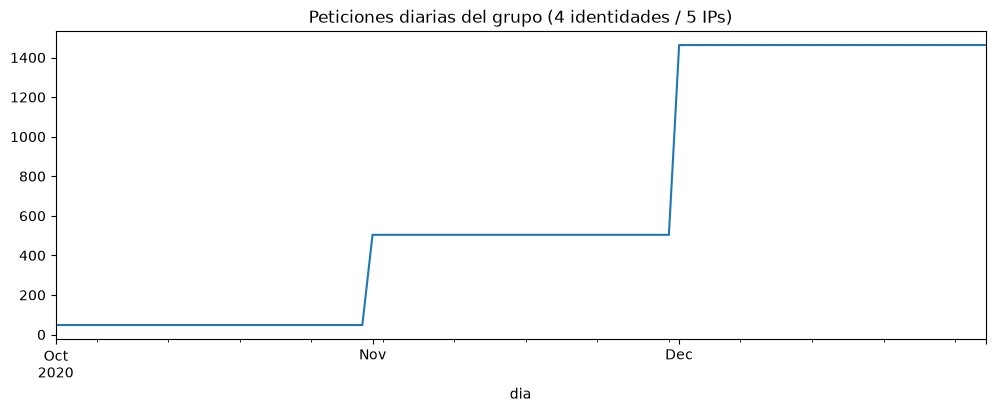

In [8]:
grp = engine.query("""
    WITH g AS (SELECT user_id, count(DISTINCT src_ip) AS ips FROM logs GROUP BY 1)
    SELECT CAST(l.timestamp_utc AS DATE) AS dia,
           count(*) AS total,
           count(*) FILTER (WHERE g.ips <= 10) AS grupo
    FROM logs l JOIN g USING (user_id)
    GROUP BY 1 ORDER BY 1
""").df()
grp["dia"] = pd.to_datetime(grp["dia"])
grp.plot(x="dia", y="grupo", figsize=(12, 4), legend=False,
         title="Peticiones diarias del grupo (4 identidades / 5 IPs)")
display(grp.groupby(grp["dia"].dt.to_period("M"))["grupo"].agg(["min", "max", "sum"]))

In [9]:
def cambio_25dic(col):
    return engine.query(f"""
        SELECT {col} AS valor,
               round(count(*) FILTER (WHERE timestamp_utc <  TIMESTAMPTZ '2020-12-25 00:00:00+00') / 10.0, 1) AS media_dia_antes,
               round(count(*) FILTER (WHERE timestamp_utc >= TIMESTAMPTZ '2020-12-25 00:00:00+00') /  7.0, 1) AS media_dia_despues
        FROM logs WHERE timestamp_utc >= TIMESTAMPTZ '2020-12-15 00:00:00+00'
        GROUP BY 1 ORDER BY (media_dia_despues - media_dia_antes) DESC
    """).df()

for col in ["user_agent", "referer", "status_code", "x_site_id", "x_token_type", "user_id"]:
    print("--", col)
    display(cambio_25dic(col).head(8))

display(engine.query("""
    WITH primera AS (SELECT src_ip, min(timestamp_utc) AS t0 FROM logs GROUP BY 1)
    SELECT count(*) FILTER (WHERE t0 >= TIMESTAMPTZ '2020-12-25 00:00:00+00') AS ips_nuevas_desde_25dic,
           count(*) AS ips_totales
    FROM primera
""").df())

-- user_agent


,valor,media_dia_antes,media_dia_despues
0,PostmanRuntime/7.25.0,121.0,310.0
1,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,7353.7,7394.1
2,Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebK...,7340.1,7374.7
3,Mozilla/5.0 (Windows NT 10.0) AppleWebKit/537....,7385.2,7390.6
4,wget,443.1,448.1
5,Scrapy/2.3.0 (+https://scrapy.org),510.9,509.0
6,crawler4j,509.0,505.9
7,Mozilla/5.0 (Macintosh; Intel Mac OS XÊx.y; rv...,7378.8,7375.6


-- referer


,valor,media_dia_antes,media_dia_despues
0,https://mercadolibre.com/billing,38305.0,38494.0
1,google.com,71.3,71.7
2,NaN,71.7,71.3


-- status_code


...

-- x_token_type


,valor,media_dia_antes,media_dia_despues
0,TEST,3679.1,3856.1
1,ATUSER,34768.9,34780.9


-- user_id


,valor,media_dia_antes,media_dia_despues
0,websecuser,1226.5,1289.6
1,developuser,1217.7,1277.0
2,websectest,1234.9,1289.6
3,drinksuser,1176.8,1196.7
4,sekanibuyer,1194.4,1210.3
5,ermiasbuyer,1191.3,1206.4
6,azielbuyer,1185.6,1196.9
7,liambuyer,1182.6,1192.7


,ips_nuevas_desde_25dic,ips_totales
0,0,5726


In [10]:
BASE = """
    WITH g AS (SELECT user_id, count(DISTINCT src_ip) AS ips FROM logs GROUP BY 1),
    inv AS (SELECT x_invoice_id, count(DISTINCT user_id) AS n_ident FROM logs GROUP BY 1)
"""
print("== Exposición del grupo sobre facturas fuera del conjunto compartido ==")
display(engine.query(BASE + """
    SELECT count(*) AS peticiones_grupo,
           count(*) FILTER (WHERE inv.n_ident < 31) AS a_facturas_fuera_del_conjunto,
           count(*) FILTER (WHERE inv.n_ident < 31 AND l.status_code // 100 = 2) AS fuera_con_2xx,
           count(DISTINCT l.x_invoice_id) FILTER (WHERE inv.n_ident < 31) AS facturas_fuera_totales,
           count(DISTINCT l.x_invoice_id) FILTER (WHERE inv.n_ident < 31 AND l.status_code // 100 = 2) AS facturas_fuera_con_2xx
    FROM logs l JOIN g USING (user_id) JOIN inv USING (x_invoice_id)
    WHERE g.ips <= 10
""").df())

print("== Códigos de respuesta del grupo sobre esas facturas ==")
display(engine.query(BASE + """
    SELECT l.status_code, count(*) AS n
    FROM logs l JOIN g USING (user_id) JOIN inv USING (x_invoice_id)
    WHERE g.ips <= 10 AND inv.n_ident < 31
    GROUP BY 1 ORDER BY n DESC
""").df())

print("== Referer y sitio usados por el grupo ==")
display(engine.query(BASE + """
    SELECT l.referer, l.x_site_id, count(*) AS n
    FROM logs l JOIN g USING (user_id) WHERE g.ips <= 10
    GROUP BY 1, 2 ORDER BY n DESC
""").df())

== Exposición del grupo sobre facturas fuera del conjunto compartido ==


,peticiones_grupo,a_facturas_fuera_del_conjunto,fuera_con_2xx,facturas_fuera_totales,facturas_fuera_con_2xx
0,61961,21029,21029,5232,5232


== Códigos de respuesta del grupo sobre esas facturas ==


,status_code,n
0,200,21029


== Referer y sitio usados por el grupo ==


,referer,x_site_id,n
0,https://mercadolibre.com/billing,MeliBR,10350
1,https://mercadolibre.com/billing,MeliMX,10219
2,https://mercadolibre.com/billing,MeliCO,10189
3,https://mercadolibre.com/billing,MeliAR,10162
4,google.com,MeliMX,2699
5,NaN,MeliAR,2661
6,google.com,MeliBR,2659
7,google.com,MeliAR,2647
8,google.com,MeliCO,2629
9,NaN,MeliBR,2615
